# PyTorch 회귀분석 실습: 당뇨병 진행도 예측 (ver.0)

**목적:** 다층 퍼셉트론(MLP)을 이용한 회귀(Regression) 모델을 PyTorch로 구현하고, 당뇨병 환자의 임상 지표로부터 1년 후 질병 진행 정도를 예측한다.

**문제 유형:** 지도학습 - 회귀(Supervised Learning - Regression)

<br>

---


## 전체 파이프라인 구성

```
[1] 데이터 로드 및 탐색 (EDA)
      ↓
[2] 데이터 분할 (Train / Validation / Test)
      ↓
[3] PyTorch Dataset & DataLoader 구성
      ↓
[4] 모델 정의 (MLP Regressor)
      ↓
[5] 손실 함수 & 옵티마이저 설정
      ↓
[6] 학습 루프 (Train / Validation)
      ↓
[7] 테스트 예측 및 성능 평가
      ↓
[8] 학습 곡선 시각화
```


---


**재현성 설정:** 아래 모든 난수 시드는 `SEED = 42`로 고정한다.



---


## 0. 라이브러리 임포트 및 재현성 설정

**설계 근거:**
- PyTorch의 난수는 `torch.manual_seed`로, NumPy의 난수는 `np.random.seed`로 별도 제어해야 한다.
- GPU 연산의 결정성(determinism)을 보장하려면 `torch.backends.cudnn.deterministic = True`가 필요하다. 단, 이 설정은 일부 연산에서 속도 저하를 유발할 수 있다.

**가정:** CUDA 가용 환경(Colab T4 GPU)을 기준으로 작성하되, CPU 환경에서도 동작하도록 `device` 변수로 추상화한다.

In [ ]:
# ── 표준 및 서드파티 라이브러리 ──────────────────────────────────────────────
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# ── 재현성(Reproducibility) 설정 ─────────────────────────────────────────────
def set_seed(seed: int = 42) -> None:
    """모든 난수 생성기의 시드를 동일하게 고정하여 실험 재현성을 보장한다.

    Args:
        seed: 고정할 시드 값 (기본값: 42)
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False  # 결정성 우선, 속도 최적화 비활성화

SEED = 42
set_seed(SEED)


# ── 연산 장치(Device) 설정 ────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Device] 사용 장치: {device}")

[Device] 사용 장치: cuda




---


## 1. 데이터 로드 및 탐색적 분석 (EDA)

### 1-1. 데이터셋 명세

| 항목 | 내용 |
|------|------|
| 출처 | `sklearn.datasets.load_diabetes` (Efron et al., 2004) |
| 표본 수 | 442명 |
| 독립변수(X) | 10개 수치형 변수: age, sex, bmi, bp, s1~s6 |
| 종속변수(y) | 기저치(baseline) 1년 후 질병 진행도 (연속형 정수) |
| 전처리 상태 | 각 피처는 **평균 중심화(mean-centering)** 및 **표준화(scaling)** 완료 |

**중요 가정:**
- 종속변수가 연속형 수치이므로 **회귀(Regression)** 문제로 정의한다.
- 이미 전처리된 데이터이므로 추가 스케일링은 불필요하다. 단, 원본 데이터 사용 시에는 `StandardScaler` 적용이 필요하다.

**한계:**
- 표본 수(n=442)가 적어 딥러닝보다 선형 회귀 계열 모델이 더 효과적일 수 있다.
- `sex` 변수가 이진(binary) 범주형임에도 수치형으로 처리된 점에 유의해야 한다.

In [ ]:
def load_and_inspect_data():
    """당뇨병 데이터셋을 로드하고 기초 통계량을 출력한다.

    Returns:
        x (np.ndarray): 독립변수 배열, shape=(442, 10)
        y (np.ndarray): 종속변수 배열, shape=(442,)
    """
    dataset = load_diabetes()
    x, y = dataset.data, dataset.target

    print("=" * 55)
    print("[데이터셋 기초 정보]")
    print(f"  독립변수 형태: {x.shape}  (샘플 수, 피처 수)")
    print(f"  종속변수 형태: {y.shape}  (샘플 수,)")
    print(f"  독립변수 dtype: {x.dtype}")
    print(f"  종속변수 dtype: {y.dtype}")
    print()
    print("[종속변수 기술통계]")
    print(f"  최솟값: {y.min():.1f}")
    print(f"  최댓값: {y.max():.1f}")
    print(f"  평균:   {y.mean():.2f}")
    print(f"  표준편차: {y.std():.2f}")
    print()
    print("[피처 이름]")
    print(" ", dataset.feature_names)
    print("=" * 55)

    return x, y


x, y = load_and_inspect_data()

[데이터셋 기초 정보]
  독립변수 형태: (442, 10)  (샘플 수, 피처 수)
  종속변수 형태: (442,)  (샘플 수,)
  독립변수 dtype: float64
  종속변수 dtype: float64

[종속변수 기술통계]
  최솟값: 25.0
  최댓값: 346.0
  평균:   152.13
  표준편차: 77.01

[피처 이름]
  ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


*s1 (tc): 총 콜레스테롤 (Total serum cholesterol)

*s2 (ldl): 저밀도 지단백 (Low-density lipoproteins)

*s3 (hdl): 고밀도 지단백 (High-density lipoproteins)

*s4 (tch): 총 콜레스테롤 / HDL 비율 (Total cholesterol / HDL)

*s5 (ltg): 혈청 중성지방 수치의 로그값 (Log of serum triglycerides level)

*s6 (glu): 혈당 수치 (Blood sugar level)



---


## 2. 데이터 분할 (Train / Validation / Test)

### 분할 전략 및 근거

**왜 3분할(Train / Val / Test)인가?**

| 세트 | 역할 | 비율 |
|------|------|------|
| Train | 모델 가중치 업데이트에 사용 | 64% |
| Validation | 에포크별 과적합 모니터링 | 16% |
| Test | 최종 성능 평가 (학습 과정에 미관여) | 20% |

**분할 로직:**
1. 전체 → (Train+Val 80%, Test 20%) 으로 1차 분할
2. Train+Val → (Train 80%, Val 20%) 으로 2차 분할
3. 최종 비율: Train ≈ 64%, Val ≈ 16%, Test ≈ 20%

**엣지 케이스:** `random_state=SEED` 고정으로 분할 결과가 항상 동일함을 보장한다.

In [ ]:
def split_data(x: np.ndarray, y: np.ndarray, test_size: float = 0.2,
               val_size: float = 0.2, seed: int = 42):
    """데이터를 Train / Validation / Test 세트로 순차 분할한다.

    Args:
        x: 독립변수 배열
        y: 종속변수 배열
        test_size: 전체 중 Test 비율 (기본값: 0.2)
        val_size: Train+Val 중 Val 비율 (기본값: 0.2)
        seed: 난수 시드

    Returns:
        (x_train, x_val, x_test, y_train, y_val, y_test) 튜플
    """
    # 1차 분할: (Train+Val) vs Test
    x_trainval, x_test, y_trainval, y_test = train_test_split(
        x, y, test_size=test_size, random_state=seed
    )
    # 2차 분할: Train vs Validation
    x_train, x_val, y_train, y_val = train_test_split(
        x_trainval, y_trainval, test_size=val_size, random_state=seed
    )

    print("[데이터 분할 결과]")
    for name, arr in [("Train", x_train), ("Val", x_val), ("Test", x_test)]:
        pct = len(arr) / len(x) * 100
        print(f"  {name:5s}: {len(arr):3d}개  ({pct:.1f}%)")

    return x_train, x_val, x_test, y_train, y_val, y_test


x_train, x_val, x_test, y_train, y_val, y_test = split_data(x, y, seed=SEED)

[데이터 분할 결과]
  Train: 282개  (63.8%)
  Val  :  71개  (16.1%)
  Test :  89개  (20.1%)




---


## 3. PyTorch Dataset & DataLoader 구성

### 변환 필요성

PyTorch 모델은 `torch.Tensor` 타입만 처리할 수 있다. NumPy 배열 → Tensor 변환 시 아래 사항에 유의한다:

| 변환 대상 | dtype 지정 이유 |
|-----------|----------------|
| X (독립변수) | `torch.float32` — 신경망 가중치의 기본 연산 정밀도 |
| y (종속변수) | `torch.float32` — MSE Loss 계산 시 float 필요. `reshape(-1, 1)`로 2D 변환 (모델 출력과 shape 일치) |

### 배치 사이즈(batch_size=64) 선택 근거

- 전체 Train 샘플 수 ≈ 283개 → 배치 64이면 1 에포크 = 약 5 iteration
- 배치 크기가 너무 크면 기울기 추정의 분산이 낮아져 local minimum에 갇힐 위험이 있다.
- 작은 배치는 노이즈가 많아 수렴이 불안정해질 수 있다.

**제한사항:** 샘플 수가 적으므로 배치 효과가 제한적이다. 전체 배치(full-batch) 방식과 성능 비교가 권장된다.

In [ ]:
def build_dataloaders(x_train, x_val, x_test,
                      y_train, y_val, y_test,
                      batch_size: int = 64):
    """NumPy 배열을 Tensor로 변환하고 DataLoader를 생성한다.

    Args:
        x_train, x_val, x_test: 독립변수 분할 배열
        y_train, y_val, y_test: 종속변수 분할 배열
        batch_size: 미니배치 크기 (기본값: 64)

    Returns:
        (train_loader, val_loader, x_test_tensor, y_test_np) 튜플
    """
    # ── NumPy → PyTorch Tensor 변환 ──────────────────────────────────────────
    # y를 (N,) → (N,1)로 reshape: 모델 출력 shape (N,1)과 일치시킴
    def to_tensors(x_arr, y_arr):
        x_t = torch.tensor(x_arr, dtype=torch.float32)
        y_t = torch.tensor(y_arr, dtype=torch.float32).reshape(-1, 1)
        return x_t, y_t

    x_train_t, y_train_t = to_tensors(x_train, y_train)
    x_val_t,   y_val_t   = to_tensors(x_val,   y_val)
    x_test_t,  _         = to_tensors(x_test,   y_test)

    # ── TensorDataset → DataLoader 구성 ─────────────────────────────────────
    train_loader = DataLoader(
        TensorDataset(x_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True    # 학습 시 매 에포크마다 데이터 순서를 섞어 편향 방지
    )
    val_loader = DataLoader(
        TensorDataset(x_val_t, y_val_t),
        batch_size=batch_size,
        shuffle=False   # 검증/테스트는 순서 고정 (재현성)
    )

    print(f"[DataLoader 구성 완료]")
    print(f"  Train DataLoader: {len(train_loader)} 배치 × {batch_size}")
    print(f"  Val   DataLoader: {len(val_loader)} 배치 × {batch_size}")
    print(f"  Test Tensor shape: {x_test_t.shape}")

    return train_loader, val_loader, x_test_t, y_test


BATCH_SIZE = 64
train_loader, val_loader, x_test_tensor, y_test_np = build_dataloaders(
    x_train, x_val, x_test, y_train, y_val, y_test, batch_size=BATCH_SIZE
)

[DataLoader 구성 완료]
  Train DataLoader: 5 배치 × 64
  Val   DataLoader: 2 배치 × 64
  Test Tensor shape: torch.Size([89, 10])




---


## 4. 모델 정의: 다층 퍼셉트론 회귀 (MLP Regressor)

### 아키텍처 설계 근거

```
Input(10) → Linear(10→64) → ReLU → Linear(64→32) → ReLU → Linear(32→1)
```

| 층 | 입력 차원 | 출력 차원 | 이유 |
|----|----------|----------|------|
| Hidden 1 | 10 | 64 | 피처 수(10)보다 충분히 큰 은닉 차원으로 표현력 확보 |
| Hidden 2 | 64 | 32 | 점진적 차원 축소로 특징 압축 |
| Output | 32 | 1 | **회귀**: 단일 연속값 출력. 출력층에 활성화 함수 없음 |

**ReLU 선택 이유:** 음수 입력을 0으로 만들어 희소 활성화(sparse activation)를 유도하며, vanishing gradient 문제가 Sigmoid/Tanh 대비 적다.

**중요:** 회귀 문제이므로 출력층에 Sigmoid/Softmax를 적용하면 안 된다. 타겟 범위(25~346)가 [0,1]을 벗어나기 때문이다.

**한계:** 현재 아키텍처는 Dropout, Batch Normalization 없이 구성되어 과적합 위험이 있다. 샘플 수가 적어 정규화 기법 추가를 권장한다.

In [ ]:
class MLPRegressor(nn.Module):
    """회귀용 다층 퍼셉트론(MLP) 모델.

    구조: Linear → ReLU → Linear → ReLU → Linear(출력)

    Args:
        input_dim: 입력 피처 수 (기본값: 10)
        hidden1: 첫 번째 은닉층 뉴런 수 (기본값: 64)
        hidden2: 두 번째 은닉층 뉴런 수 (기본값: 32)
        output_dim: 출력 차원, 회귀이므로 1 (기본값: 1)
    """

    def __init__(self, input_dim: int = 10, hidden1: int = 64,
                 hidden2: int = 32, output_dim: int = 1):
        super(MLPRegressor, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden1),   # 선형 변환: 10 → 64
            nn.ReLU(),                        # 비선형 활성화
            nn.Linear(hidden1, hidden2),      # 선형 변환: 64 → 32
            nn.ReLU(),                        # 비선형 활성화
            nn.Linear(hidden2, output_dim),   # 출력층: 32 → 1 (활성화 없음)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """순전파(Forward Pass)를 수행한다.

        Args:
            x: 입력 텐서, shape=(batch_size, input_dim)

        Returns:
            예측값 텐서, shape=(batch_size, 1)
        """
        return self.network(x)


def build_model(input_dim: int = 10, seed: int = 42) -> nn.Module:
    """모델을 초기화하고 지정 device로 이동한다.

    Args:
        input_dim: 입력 피처 수
        seed: 가중치 초기화 재현성을 위한 시드

    Returns:
        device로 이동된 MLPRegressor 모델
    """
    set_seed(seed)  # 가중치 초기화 재현성 보장
    model = MLPRegressor(input_dim=input_dim).to(device)
    return model


model = build_model(input_dim=10, seed=SEED)

# ── 모델 구조 출력 ────────────────────────────────────────────────────────────
print("[모델 아키텍처]")
print(model)
print()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[학습 가능한 총 파라미터 수: {total_params:,}]")

[모델 아키텍처]
MLPRegressor(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

[학습 가능한 총 파라미터 수: 2,817]




---


## 5. 손실 함수 및 옵티마이저 설정

### 손실 함수: MSELoss

$${L}_{MSE} = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2$$

- 회귀 문제의 표준 손실 함수: 예측값과 실제값의 차의 제곱 평균
- **이상치 민감성:** 오차를 제곱하므로 이상치(outlier)에 민감하다. 이상치가 많은 경우 MAELoss(`L1Loss`) 또는 HuberLoss를 대안으로 고려할 수 있다.

### 옵티마이저: Adam (lr=0.001)

- Adaptive Moment Estimation: 각 파라미터마다 학습률을 개별 조정하는 방식
- SGD 대비 수렴 속도가 빠르고 학습률에 덜 민감하여 초기 실험에 적합하다.
- `lr=0.001`: Adam의 권장 기본값으로, 대부분의 태스크에서 안정적인 출발점이다.

In [ ]:
def configure_training(model: nn.Module, lr: float = 0.001):
    """손실 함수와 옵티마이저를 초기화한다.

    Args:
        model: 학습 대상 모델
        lr: 학습률 (기본값: 0.001)

    Returns:
        (criterion, optimizer) 튜플
    """
    criterion = nn.MSELoss()  # 회귀 손실: 평균제곱오차
    optimizer = optim.Adam(model.parameters(), lr=lr)

    print(f"[학습 설정]")
    print(f"  손실 함수: {criterion.__class__.__name__}")
    print(f"  옵티마이저: {optimizer.__class__.__name__}  (lr={lr})")

    return criterion, optimizer


LEARNING_RATE = 0.001
criterion, optimizer = configure_training(model, lr=LEARNING_RATE)

[학습 설정]
  손실 함수: MSELoss
  옵티마이저: Adam  (lr=0.001)




---


## 6. 학습 루프 (Training Loop)

### PyTorch 학습의 표준 순서

```
for each epoch:
    [Train]
    model.train()
    for each batch:
        1. Forward Pass:  y_pred = model(x)
        2. Loss 계산:     loss = criterion(y_pred, y_true)
        3. 기울기 초기화: optimizer.zero_grad()   ← 이전 기울기 누적 방지
        4. 역전파:        loss.backward()          ← 기울기 계산
        5. 가중치 갱신:   optimizer.step()         ← 파라미터 업데이트

    [Validation]
    model.eval()
    with torch.no_grad():                         ← 기울기 계산 비활성화
        val_loss 계산 (가중치 업데이트 없음)
```

**`optimizer.zero_grad()`를 매 배치마다 호출하는 이유:** PyTorch는 기본적으로 `.backward()` 시 기울기를 누적(accumulate)한다. 초기화 없이 반복하면 기울기가 합산되어 잘못된 업데이트가 발생한다.

**`torch.no_grad()`의 역할:** 검증 단계에서는 연산 그래프를 구성할 필요가 없으므로 메모리와 연산 비용을 절약한다.

In [ ]:
def train_one_epoch(model: nn.Module, loader: DataLoader,
                    criterion: nn.Module, optimizer: optim.Optimizer) -> float:
    """1 에포크 학습을 수행하고 평균 Train Loss를 반환한다.

    Returns:
        epoch_loss: 배치 평균 MSE Loss
    """
    model.train()
    total_loss = 0.0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = model(x_batch)          # 1. Forward Pass
        loss = criterion(y_pred, y_batch) # 2. Loss 계산

        optimizer.zero_grad()             # 3. 기울기 초기화
        loss.backward()                   # 4. 역전파
        optimizer.step()                  # 5. 가중치 갱신

        total_loss += loss.item()

    return total_loss / len(loader)  # 배치 평균 반환


def evaluate(model: nn.Module, loader: DataLoader,
             criterion: nn.Module) -> float:
    """검증(Validation) 손실을 계산한다. 가중치 업데이트 없음.

    Returns:
        epoch_loss: 배치 평균 MSE Loss
    """
    model.eval()
    total_loss = 0.0

    with torch.no_grad():  # 기울기 계산 비활성화
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()

    return total_loss / len(loader)


def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs: int = 500, print_every: int = 50):
    """전체 학습 루프를 실행하고 손실 기록을 반환한다.

    Args:
        num_epochs: 총 에포크 수 (기본값: 500)
        print_every: 로그 출력 주기 (기본값: 50)

    Returns:
        (train_losses, val_losses): 에포크별 손실 기록 리스트
    """
    train_losses, val_losses = [], []

    for epoch in range(1, num_epochs + 1):
        t_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss = evaluate(model, val_loader, criterion)

        train_losses.append(t_loss)
        val_losses.append(v_loss)

        if epoch % print_every == 0 or epoch == 1:
            print(f"[Epoch {epoch:4d}/{num_epochs}]  "
                  f"Train Loss: {t_loss:8.2f}  |  Val Loss: {v_loss:8.2f}")

    return train_losses, val_losses


NUM_EPOCHS = 500
train_losses, val_losses = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=NUM_EPOCHS, print_every=50
)

[Epoch    1/500]  Train Loss: 28090.92  |  Val Loss: 32609.22
[Epoch   50/500]  Train Loss: 19211.21  |  Val Loss: 21897.01
[Epoch  100/500]  Train Loss:  4140.79  |  Val Loss:  3672.50
[Epoch  150/500]  Train Loss:  3759.32  |  Val Loss:  2968.92
[Epoch  200/500]  Train Loss:  3516.52  |  Val Loss:  2695.02
[Epoch  250/500]  Train Loss:  3334.05  |  Val Loss:  2507.91
[Epoch  300/500]  Train Loss:  2931.36  |  Val Loss:  2384.39
[Epoch  350/500]  Train Loss:  3142.29  |  Val Loss:  2319.51
[Epoch  400/500]  Train Loss:  3003.78  |  Val Loss:  2277.53
[Epoch  450/500]  Train Loss:  3002.81  |  Val Loss:  2243.72
[Epoch  500/500]  Train Loss:  2927.27  |  Val Loss:  2218.40




---


## 7. 테스트 예측 및 최종 성능 평가

### 텐서 → NumPy 변환 단계의 필요성

```python
y_pred_tensor                    # GPU 메모리, 연산 그래프 포함
  .detach()                      # 연산 그래프에서 분리 (기울기 추적 해제)
  .cpu()                         # GPU → CPU 메모리로 이동
  .numpy()                       # NumPy 배열로 변환
  .flatten()                     # (N,1) → (N,) 로 1차원화
```

### 평가 지표 해석

| 지표 | 수식 | 해석 |
|------|------|------|
| MSE | $\frac{1}{N}\sum(\hat{y}-y)^2$ | 제곱 오차 평균 (단위: $y^2$) |
| RMSE | $\sqrt{MSE}$ | 실제 오차의 평균 크기 (단위: $y$와 동일) |
| R² | $1 - \frac{SS_{res}}{SS_{tot}}$ | 설명된 분산 비율. 1에 가까울수록 좋음 |

In [ ]:
def predict_and_evaluate(model: nn.Module, x_test_tensor: torch.Tensor,
                         y_test_np: np.ndarray) -> dict:
    """테스트 데이터에 대한 예측 수행 및 회귀 지표를 계산한다.

    Args:
        model: 학습 완료된 모델
        x_test_tensor: 테스트 입력 텐서
        y_test_np: 테스트 정답 NumPy 배열

    Returns:
        metrics: {mse, rmse, r2, y_pred} 딕셔너리
    """
    model.eval()

    with torch.no_grad():
        y_pred_tensor = model(x_test_tensor.to(device))

    # GPU 텐서 → CPU NumPy 변환
    y_pred = y_pred_tensor.cpu().numpy().flatten()

    mse  = mean_squared_error(y_test_np, y_pred)
    rmse = mse ** 0.5
    r2   = r2_score(y_test_np, y_pred)

    print("=" * 45)
    print("[최종 테스트 성능 평가]")
    print(f"  MSE  : {mse:8.4f}")
    print(f"  RMSE : {rmse:8.4f}  ← 예측 오차의 평균 크기")
    print(f"  R²   : {r2:8.4f}  ← 1에 가까울수록 우수")
    print("=" * 45)
    print()
    print("[해석]")
    print(f"  타겟 평균: {y_test_np.mean():.2f}, 표준편차: {y_test_np.std():.2f}")
    print(f"  RMSE/std = {rmse/y_test_np.std():.3f}  "
          f"(1에 가까울수록 예측력이 표준편차 수준에 불과함)")

    return {"mse": mse, "rmse": rmse, "r2": r2, "y_pred": y_pred}


metrics = predict_and_evaluate(model, x_test_tensor, y_test_np)

[최종 테스트 성능 평가]
  MSE  : 2913.7008
  RMSE :  53.9787  ← 예측 오차의 평균 크기
  R²   :   0.4501  ← 1에 가까울수록 우수

[해석]
  타겟 평균: 145.78, 표준편차: 72.79
  RMSE/std = 0.742  (1에 가까울수록 예측력이 표준편차 수준에 불과함)




---


## 8. 결과 시각화

두 가지 플롯을 통해 모델 성능을 진단한다:

1. **학습 곡선(Learning Curve):** Train/Val Loss의 에포크별 추이 → 과적합 여부 판단
2. **실제값 vs 예측값 산점도:** 점이 대각선(y=x)에 가까울수록 예측 정확도가 높음

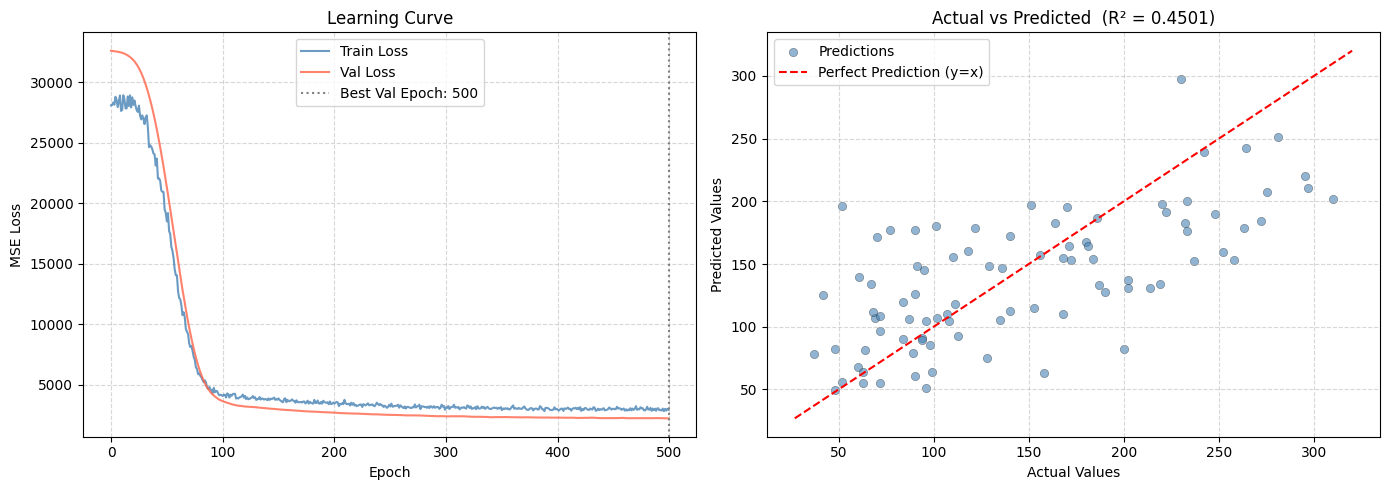

[진단] Val Loss 최솟값 에포크: 500
       최종 에포크(500)와 차이가 클수록 조기 종료(Early Stopping)가 유효할 수 있음


In [ ]:
def plot_results(train_losses: list, val_losses: list,
                 y_true: np.ndarray, y_pred: np.ndarray,
                 r2: float) -> None:
    """학습 곡선과 예측값-실제값 산점도를 나란히 시각화한다."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── (좌) 학습 곡선 ────────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(train_losses, label="Train Loss", color="steelblue", alpha=0.8)
    ax.plot(val_losses,   label="Val Loss",   color="tomato",    alpha=0.8)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title("Learning Curve")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

    # 과적합 진단: Val Loss 최솟값 표시
    best_epoch = int(np.argmin(val_losses)) + 1
    ax.axvline(best_epoch, color="gray", linestyle=":",
               label=f"Best Val Epoch: {best_epoch}")
    ax.legend()

    # ── (우) 실제값 vs 예측값 ─────────────────────────────────────────────────
    ax = axes[1]
    ax.scatter(y_true, y_pred, alpha=0.6, color="steelblue", edgecolors="k",
               linewidths=0.3, label="Predictions")

    # 완벽한 예측선 (y = x)
    lim_min = min(y_true.min(), y_pred.min()) - 10
    lim_max = max(y_true.max(), y_pred.max()) + 10
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            "r--", linewidth=1.5, label="Perfect Prediction (y=x)")

    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.set_title(f"Actual vs Predicted  (R² = {r2:.4f})")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()
    print(f"[진단] Val Loss 최솟값 에포크: {best_epoch}")
    print(f"       최종 에포크(500)와 차이가 클수록 조기 종료(Early Stopping)가 유효할 수 있음")


plot_results(train_losses, val_losses, y_test_np, metrics["y_pred"], metrics["r2"])



---


## 9. 실험 요약 및 향후 개선 방향

### 실험 결과 요약

| 항목 | 내용 |
|------|------|
| 모델 | MLP (10→64→32→1) |
| 옵티마이저 | Adam (lr=0.001) |
| 손실 함수 | MSELoss |
| 에포크 | 500 |
| 배치 크기 | 64 |

<br>

---



### 검증된 사실
- PyTorch 회귀 모델 학습의 전체 파이프라인(데이터 로드 → 전처리 → 모델 정의 → 학습 → 평가)을 완성했다.
- RMSE ≈ 53, R² ≈ 0.45: 분산의 약 45%만 설명하기에 → 설명력 부족

<br>

---


### 개선 가능 방향

| 방향 | 방법 |
|------|------|
| 과적합 완화 | Dropout, Weight Decay(`optim.Adam(weight_decay=1e-4)`) 추가 |
| 조기 종료 | Early Stopping (val_loss 기준 patience 설정) |
| 모델 비교 | sklearn의 Ridge, Lasso, RandomForest와 성능 비교 |
| 학습률 스케줄 | `torch.optim.lr_scheduler.ReduceLROnPlateau` 적용 |
| 데이터 한계 | n=442로 적으므로 K-Fold Cross Validation으로 일반화 성능 추정 권장 |

In [ ]:
# ── 실험 설정 및 최종 결과 한눈에 확인 ───────────────────────────────────────
print("=" * 55)
print("           실험 최종 요약 (Experiment Summary)")
print("=" * 55)
print(f"  시드(Seed)       : {SEED}")
print(f"  디바이스(Device) : {device}")
print(f"  배치 크기        : {BATCH_SIZE}")
print(f"  에포크           : {NUM_EPOCHS}")
print(f"  학습률(lr)       : {LEARNING_RATE}")
print("-" * 55)
print(f"  [Test]  MSE  : {metrics['mse']:.4f}")
print(f"  [Test]  RMSE : {metrics['rmse']:.4f}")
print(f"  [Test]  R²   : {metrics['r2']:.4f}")
print("=" * 55)

           실험 최종 요약 (Experiment Summary)
  시드(Seed)       : 42
  디바이스(Device) : cuda
  배치 크기        : 64
  에포크           : 500
  학습률(lr)       : 0.001
-------------------------------------------------------
  [Test]  MSE  : 2913.7008
  [Test]  RMSE : 53.9787
  [Test]  R²   : 0.4501
